In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from h5 import HDFArchive
from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

Starting serial run at: 2026-07-12 20:42:08.295664
/home/carlo/Desktop/qc/scripts/plot.py:37: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel('$q_z/\pi$')
/home/carlo/Desktop/qc/scripts/plot.py:41: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_ylabel('$Q_z/\pi$')


SCBA: nk=50^2, niw=128, T=0.1000, mu=0.0000, v=0.050  [numpy.fft]
Converged at step    4  diff=3.636e-11  mu=-0.314818


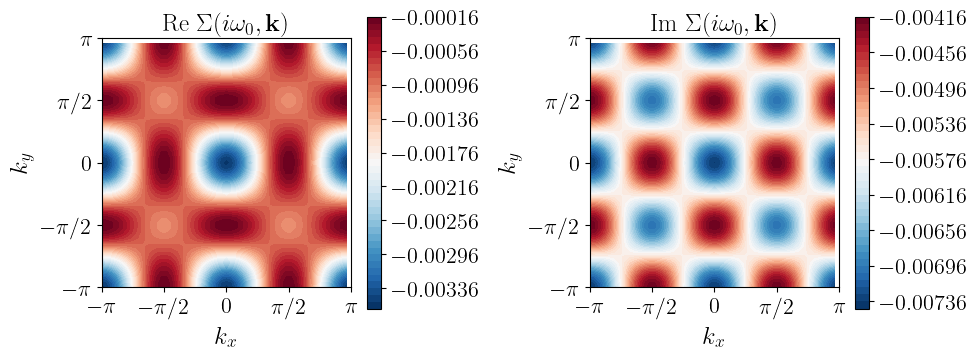

In [ ]:
from scripts.scba import *

lat = LATTICE(dim=2)
nk = 50
bz = BZ(lat, nk=nk)

kx = np.linspace(-np.pi, np.pi, nk, endpoint=False)
ky = np.linspace(-np.pi, np.pi, nk, endpoint=False)
kx, ky = np.meshgrid(kx, ky, indexing='ij')

niw = 128
beta = 1/0.1
n = 0.85
scba = SCBA(lat, bz, niw)
scba.run(0.05, beta, n, ibz=True)

S_iwk = bz.unfold_f_iwk(scba.S_iwk)

S_grid = S_iwk.reshape(niw,nk,nk)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

c0 = axes[0].contourf(kx, ky, S_grid[0].real, levels=50, cmap='RdBu_r')
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r'Re $\Sigma(i\omega_0, \mathbf{k})$')

c1 = axes[1].contourf(kx, ky, S_grid[0].imag, levels=50, cmap='RdBu_r')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r'Im $\Sigma(i\omega_0, \mathbf{k})$')

for ax in axes:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1366: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1367: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/numpy/ma/core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


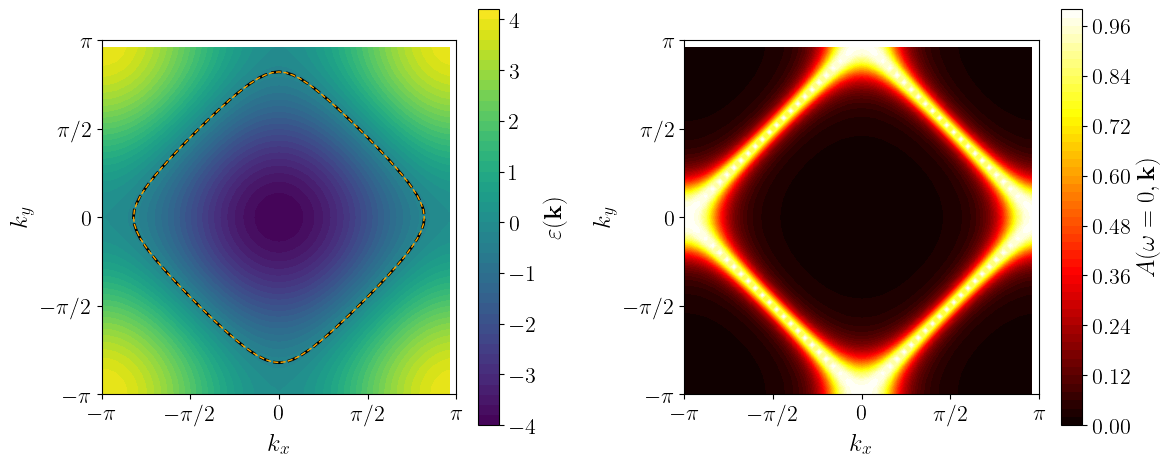

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

lat = LATTICE(dim=2)
bz = BZ(lat, nk=nk, ibz=False)

e_k = bz.e_k.reshape(nk,nk)
Sk0_real = S_iwk[0].reshape(nk,nk)

kx = bz.k_vecs[:,0].reshape(nk,nk)
ky = bz.k_vecs[:,1].reshape(nk,nk)
kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)
Sk0_real = np.roll(np.roll(Sk0_real, nk//2, axis=0), nk//2, axis=1)

G_k_n0 = 1.0 / (1j * np.pi / beta - e_k - Sk0_real)
A_k0 = -G_k_n0.imag / np.pi

cf = axs[0].contourf(kx, ky, e_k - Sk0_real, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')

mu = get_mu(e_k=bz.e_k, n_goal=0.85, beta=1/0.1)
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)
axs[0].contour(kx, ky, e_k - Sk0_real, levels=[mu], colors='orange', linewidths=1)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

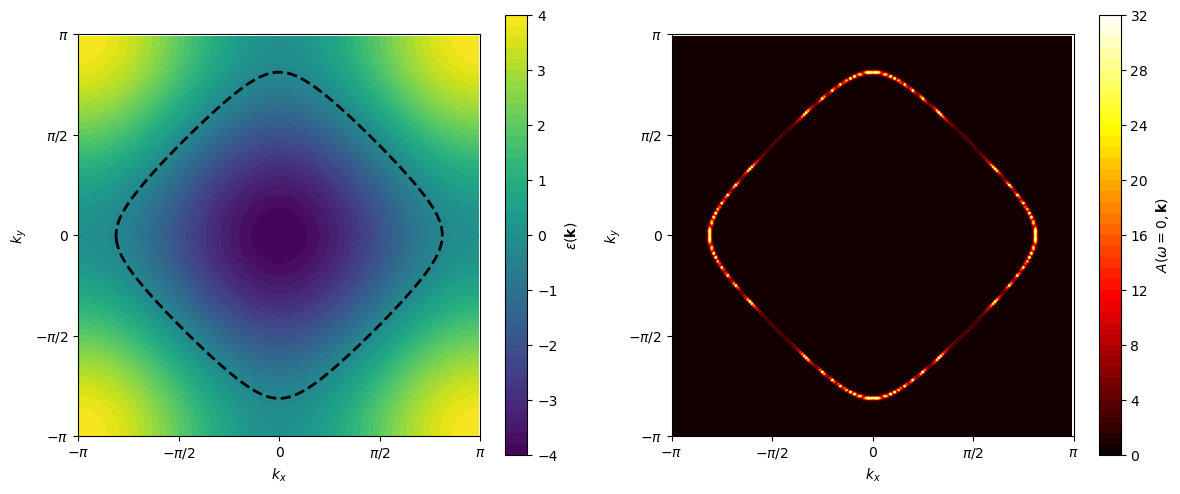

In [ ]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

mu = get_mu(e_k=lat.e_k, n_goal=0.9, beta=1/1)
eta = 0.01
A_k0 = (1/np.pi) * eta / (eta**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

tp : -0.2, mu : [-0.8517850759228668, -0.6716672852022249, -0.46057022123212055], n = [np.float64(0.8), np.float64(0.8999999999998523), np.float64(1.0000000000000262)]
tp : 0.0, mu : [-0.43826440547706147, -0.19845687535815118, 3.907985046680551e-14], n = [np.float64(0.7999999999999953), np.float64(0.8999999999999952), np.float64(1.0000000000000207)]
tp : 0.2, mu : [-0.11835108272199893, 0.19757301236606614, 0.4605702212320972], n = [np.float64(0.8000000000001253), np.float64(0.9000000000000007), np.float64(0.9999999999999641)]


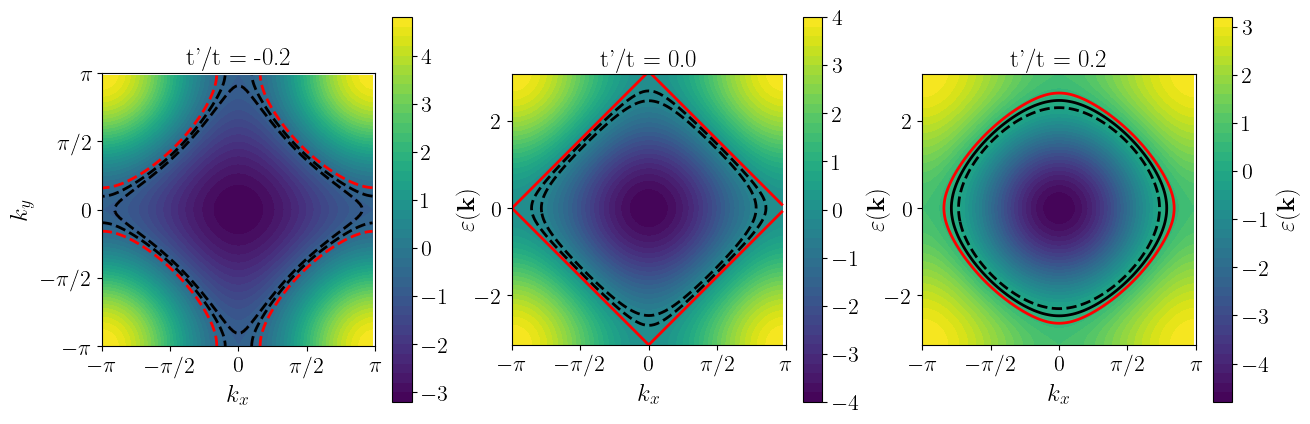

In [116]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

tp_list = [-0.2, 0., 0.2]
for i, tp in enumerate([-0.2, 0., 0.2]):

    lat = LATTICE(dim=2, tp=tp)
    nk = 100

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.1
    n_list = [0.8, 0.9, 1.]
    mu_list = [get_mu(e_k=lat.e_k, n_goal=n, beta=1/T) for n in n_list]
    n_check = [2*np.mean(1/(np.exp((lat.e_k-mu)/T)+1)) for mu in mu_list]

    cf = axs[i].contourf(kx, ky, e_k, levels=50)
    plt.colorbar(cf, ax=axs[i], label=r'$\varepsilon(\mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    axs[i].contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)
    print(f'tp : {tp}, mu : {mu_list}, n = {n_check}')

    axs[i].set_title(f"t'/t = {tp}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'
<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'
/home/carlo/Desktop/qc/scripts/plot.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #bbox_to_anchor=(0.63, 0.08, 1, 1),


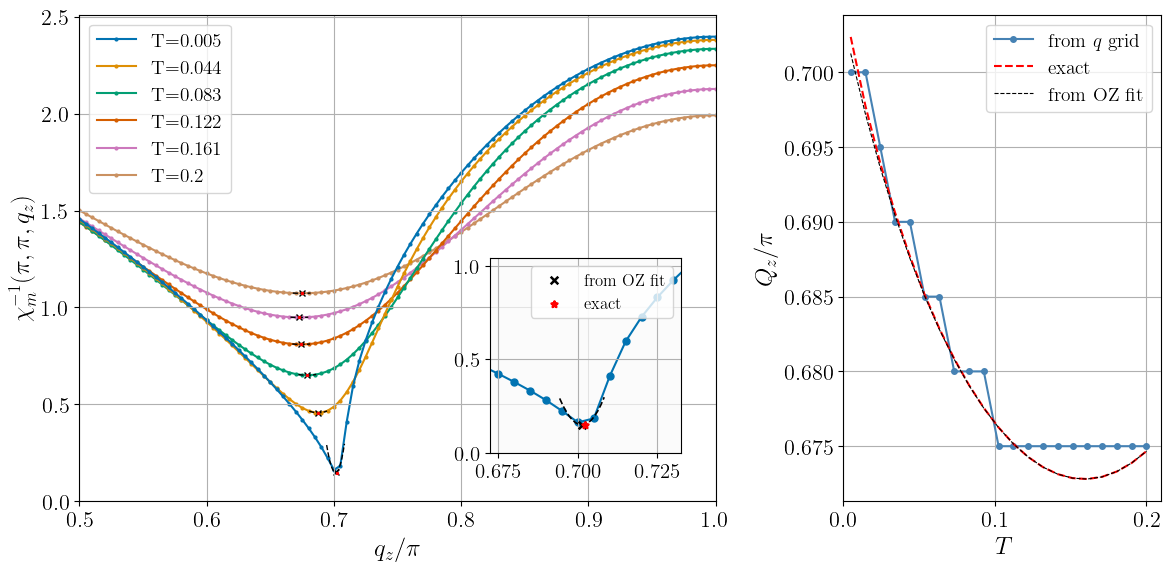

In [29]:
n = 0.745
U = 3

with HDFArchive(f"data/chimin/tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

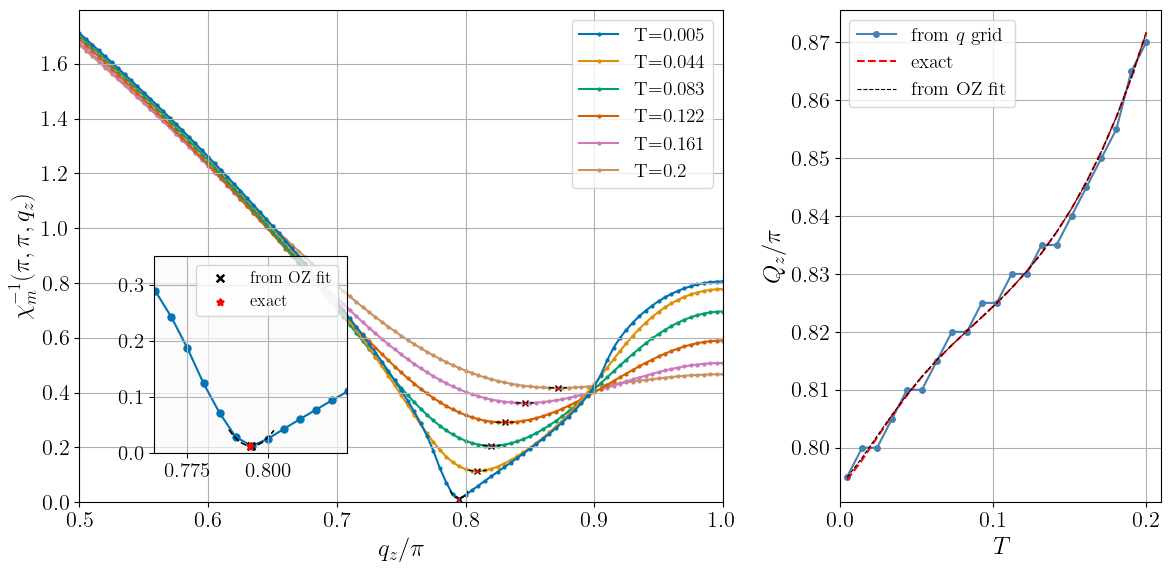

In [26]:
n = 0.8485
U = 3
tp = 0.1

with HDFArchive(f"data/chimin/tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'
<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'


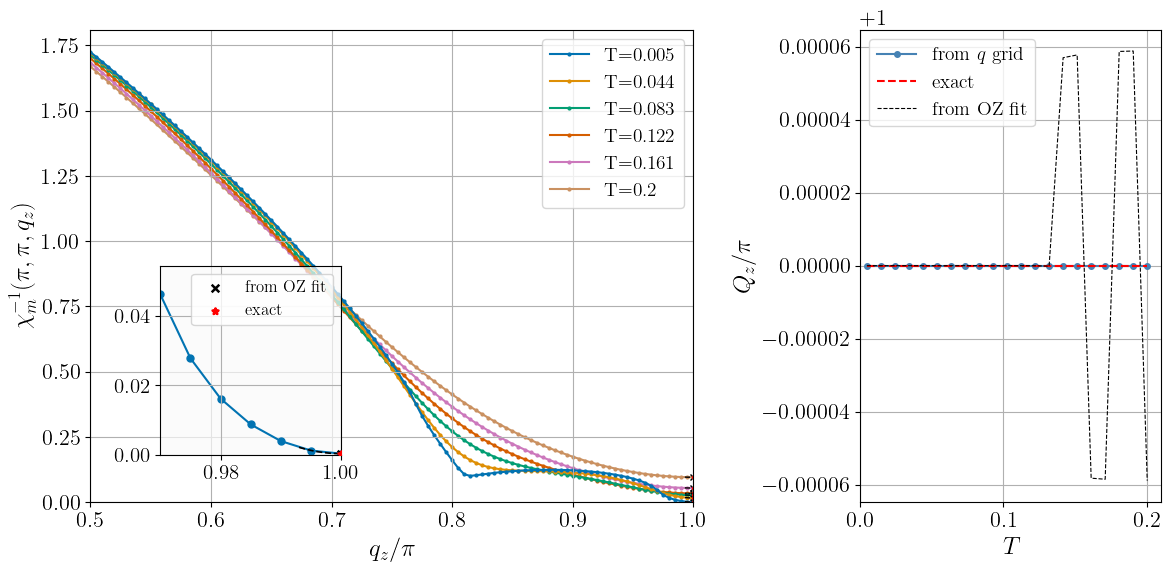

In [25]:
n = 0.88493
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/chimin/tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

{'fit': False, 'xi_range': [0, 0, 0.0005], 'fit_grid_pts': False, 'n': array([0.735, 0.74 , 0.745, 0.75 , 0.755]), 'get_xi': True, 'OZ_weight': array([[0.00269425, 0.00312454, 0.00369851, 0.00508623, 0.0053252 ,
        0.0055016 , 0.00617194, 0.00692386, 0.00701986, 0.00860198,
        0.0082521 , 0.01223677, 0.01058411, 0.01359674, 0.01211186],
       [0.00268066, 0.00314747, 0.00369449, 0.00428612, 0.00581954,
        0.00521815, 0.0062041 , 0.00691743, 0.00785291, 0.008658  ,
        0.00901307, 0.00976142, 0.0105376 , 0.01127543, 0.01208169],
       [0.00243319, 0.00310853, 0.00366537, 0.00509148, 0.00486908,
        0.00549941, 0.0064002 , 0.00669681, 0.00700152, 0.00823958,
        0.01060922, 0.00978494, 0.00989341, 0.01073957, 0.01188296],
       [0.00269082, 0.00310294, 0.00357879, 0.00426996, 0.00460145,
        0.00517895, 0.00622568, 0.00711615, 0.00737475, 0.00820315,
        0.00886366, 0.01073794, 0.01035509, 0.01140232, 0.01182707],
       [0.00253905, 0.00303234, 0.00

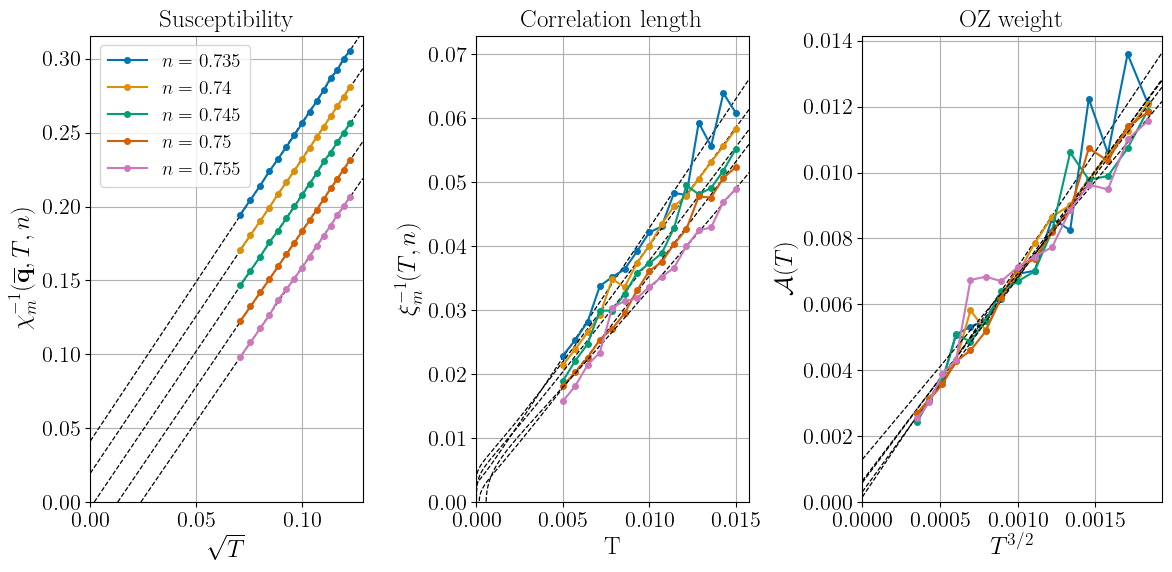

In [42]:
U = 3
tp = 0.

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

print(data)
plot_scaling(data, x_exp=(0.5, 1., 1.5), fit=True, right='OZ')
plt.show()

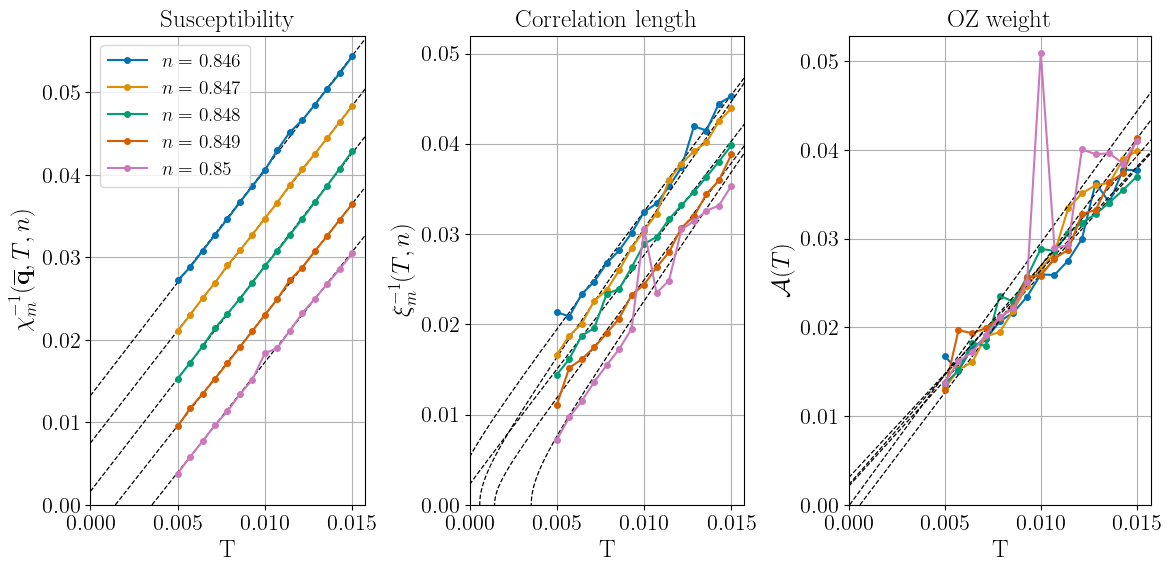

In [38]:
U = 3
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1., 1., 1.), fit=True, right='OZ')
plt.show()

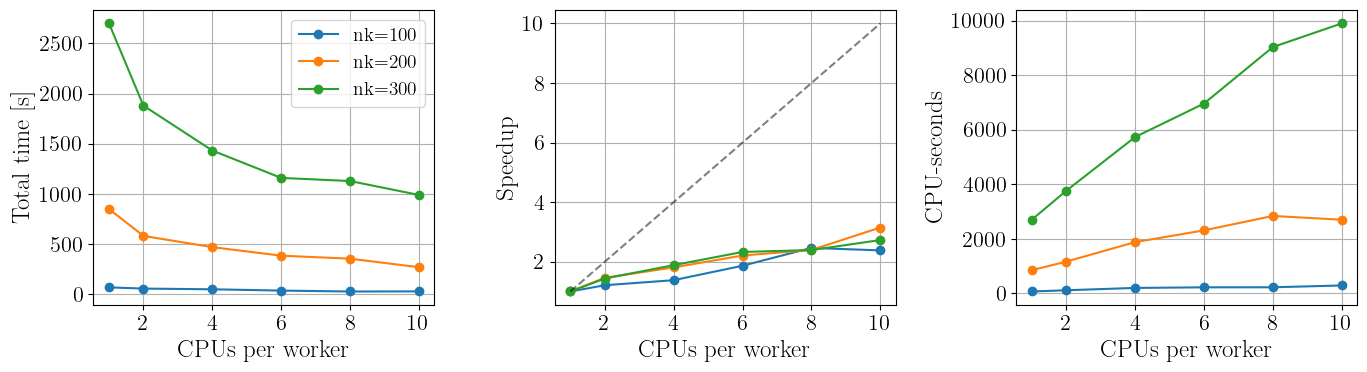

In [4]:
import numpy as np
import matplotlib.pyplot as plt

cpw = np.array([1, 2, 4, 6, 8, 10])
times = np.array([
    [69, 57, 50, 37, 28, 29],
    #[80, 46, 42, 35, 26, 24],
    [850, 582, 470, 385, 355, 270],
    [2700, 1880, 1433, 1160, 1129, 990]
])

nk = [100, 200, 300]

fig, ax = plt.subplots(1, 3, figsize=(14,4))

# Wall time
for i, n in enumerate(nk):
    ax[0].plot(cpw, times[i], 'o-', label=f"nk={n}")
ax[0].set_xlabel("CPUs per worker")
ax[0].set_ylabel("Total time [s]")
ax[0].legend()

# Speedup
for i, n in enumerate(nk):
    speedup = times[i,0] / times[i]
    ax[1].plot(cpw, speedup, 'o-', label=f"nk={n}")
ax[1].plot(cpw, cpw, '--k', alpha=0.5, label="Ideal")
ax[1].set_xlabel("CPUs per worker")
ax[1].set_ylabel("Speedup")

# CPU cost
for i, n in enumerate(nk):
    cpu_cost = cpw * times[i]
    ax[2].plot(cpw, cpu_cost, 'o-', label=f"nk={n}")
ax[2].set_xlabel("CPUs per worker")
ax[2].set_ylabel("CPU-seconds")

for a in ax:
    a.grid()

plt.tight_layout()
plt.show()

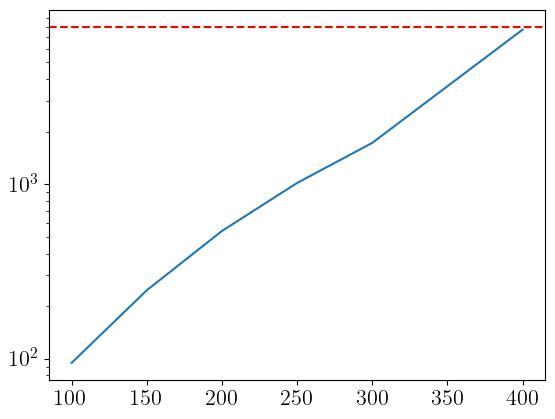

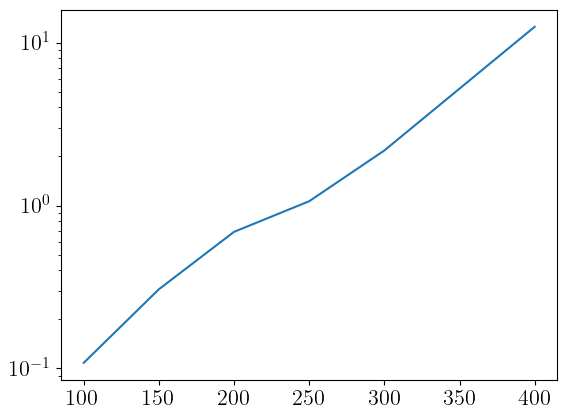

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot([100,150,200,250,300,400], np.array([1135,2960,6475,12210,20730,92500])/12)
plt.axhline(y=500*1024/64, linestyle='--', color='red')
plt.yscale('log')
plt.show()

plt.cla()
plt.plot([100,150,200,250,300,400], np.array([52,147,331,510,1045,6000])*7.5/3600)
plt.yscale('log')
plt.show()

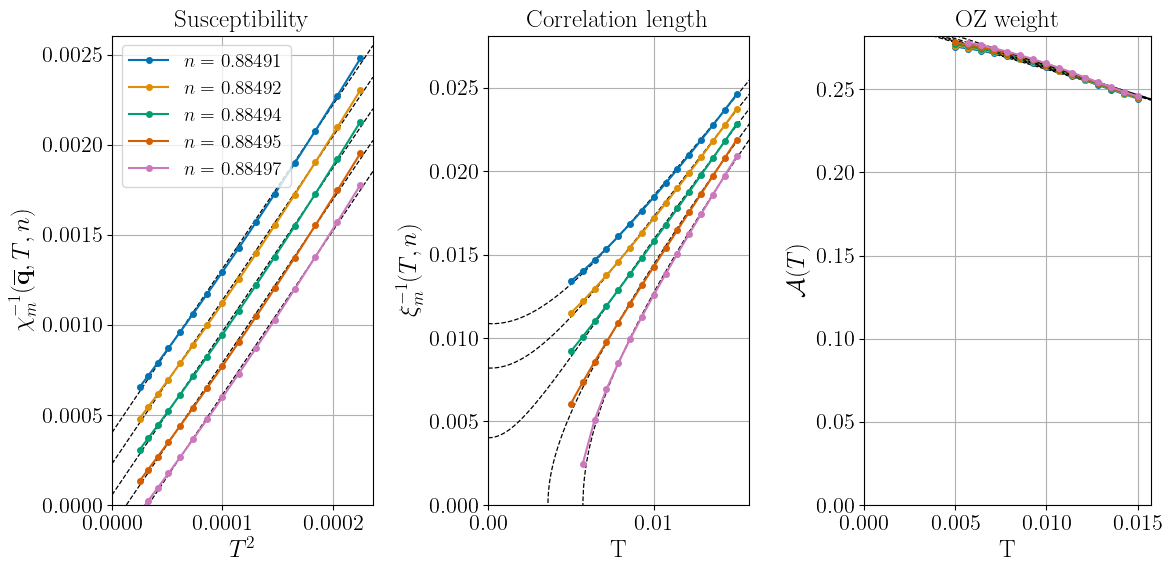

In [39]:
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.), fit=True, right='OZ')
plt.show()

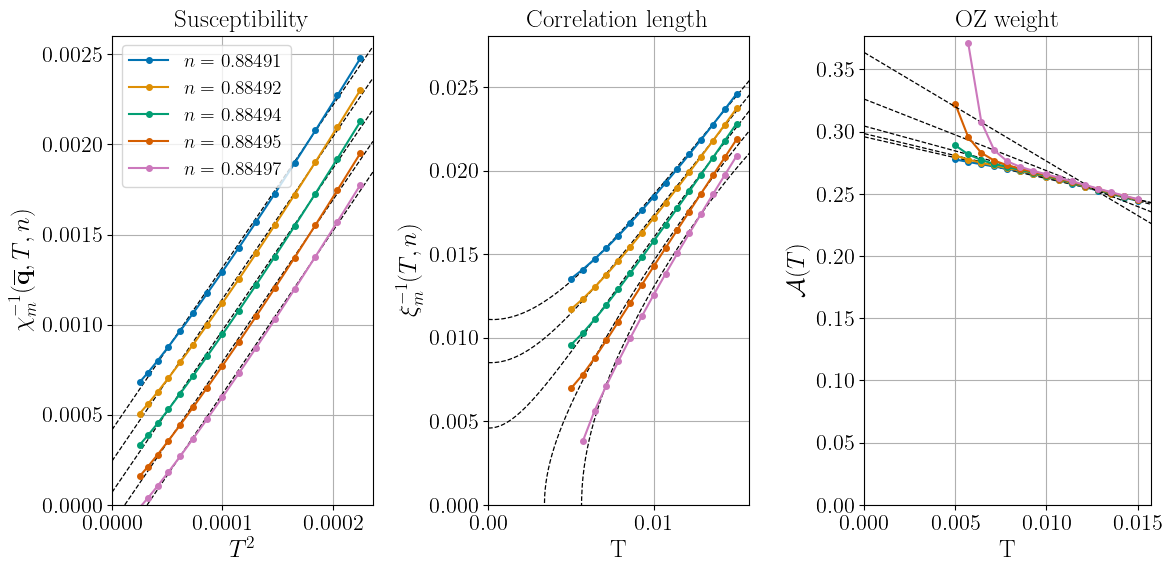

In [2]:
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h51", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.), fit=True, right='OZ')
plt.show()

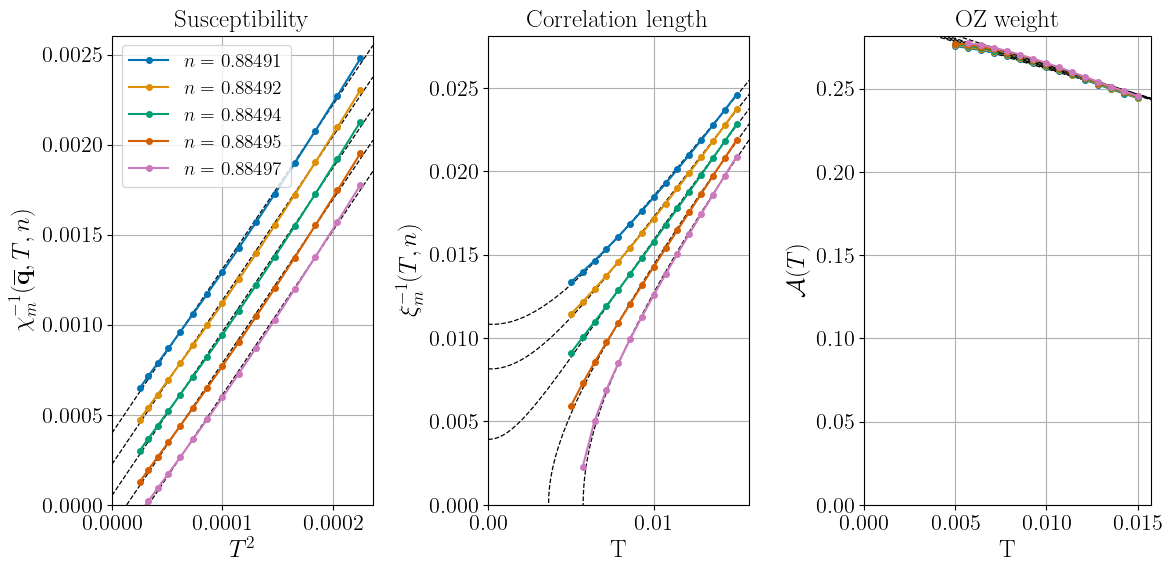

In [5]:
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h51", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.), fit=True, right='OZ')
plt.show()

<unknown>:37: SyntaxWarning: invalid escape sequence '\p'
<unknown>:41: SyntaxWarning: invalid escape sequence '\p'
<unknown>:37: SyntaxWarning: invalid escape sequence '\p'
<unknown>:41: SyntaxWarning: invalid escape sequence '\p'


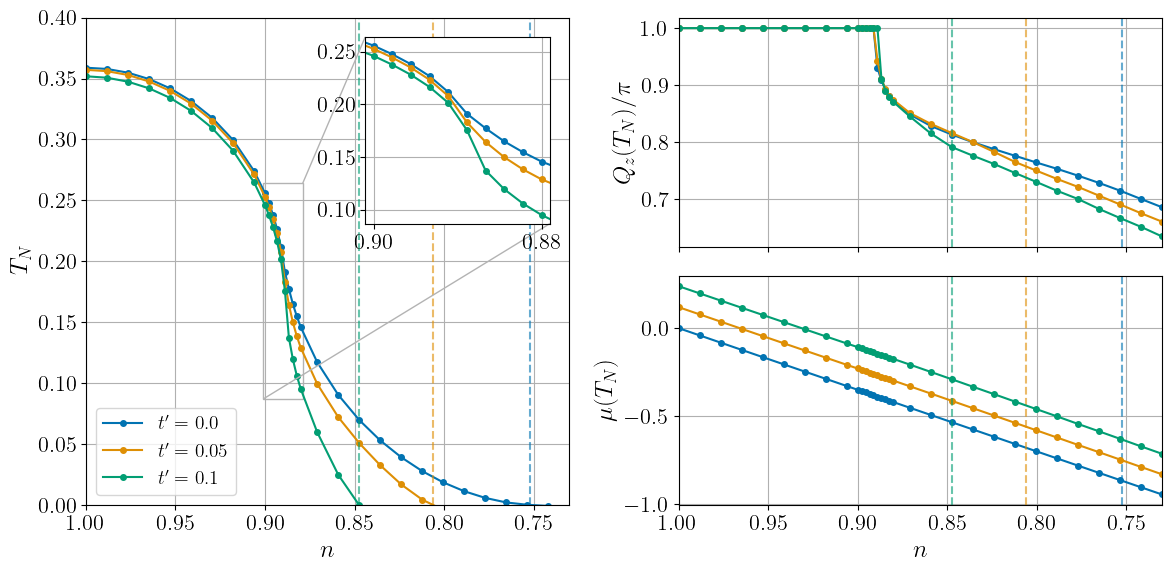

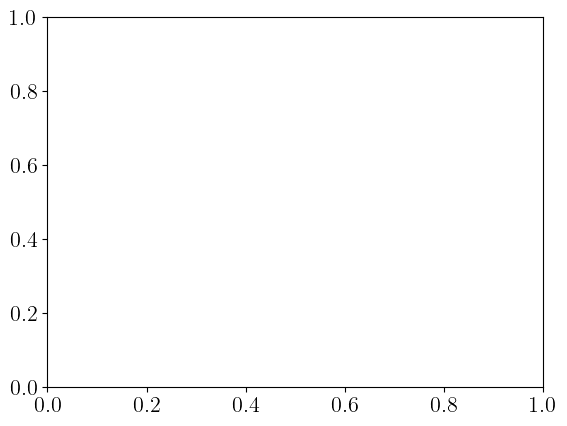

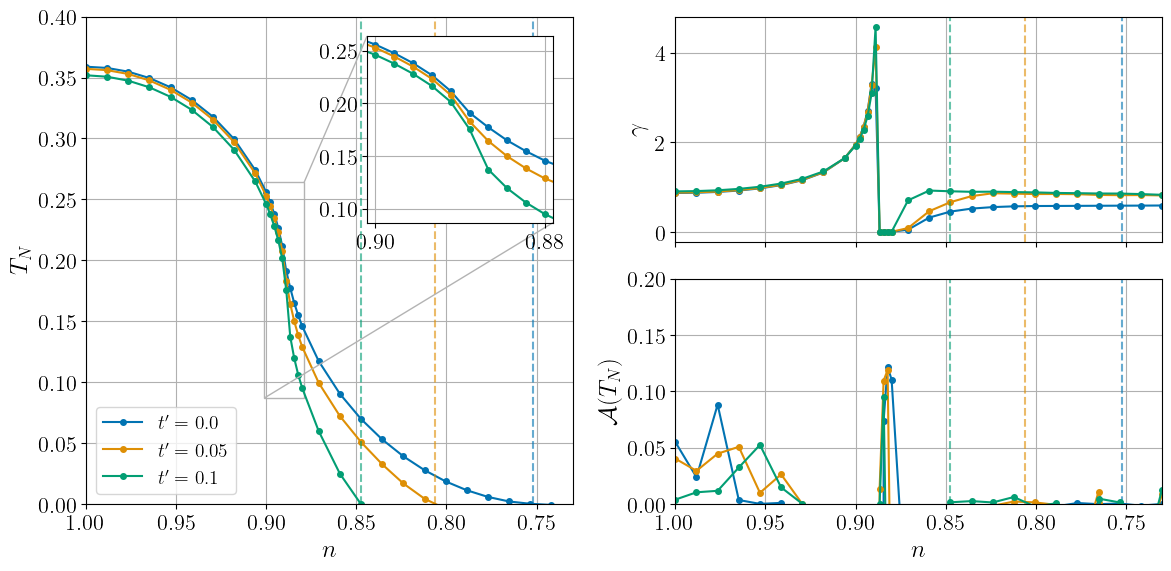

In [33]:
U = 3
tp_list = [0., 0.05, 0.1]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.879, 0.901], subplots='commens')
plt.show()

plt.cla()
plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.879, 0.901], subplots='scaling')
plt.show()

/home/carlo/Desktop/qc/scripts/plot.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  zorder=-i


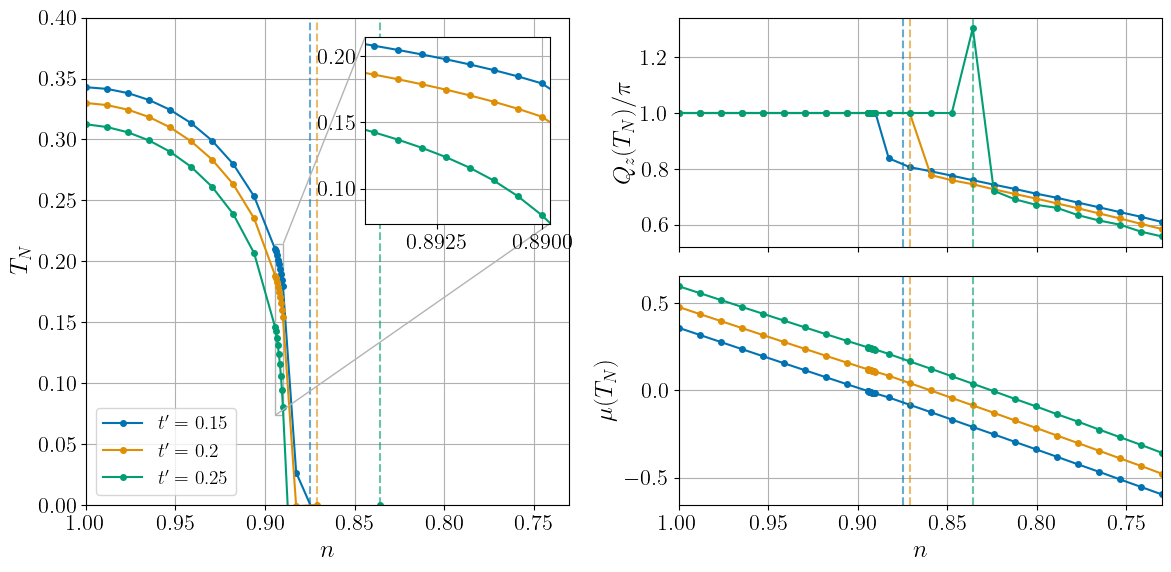

/home/carlo/Desktop/qc/scripts/plot.py:33: RuntimeWarning: overflow encountered in power
  gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])


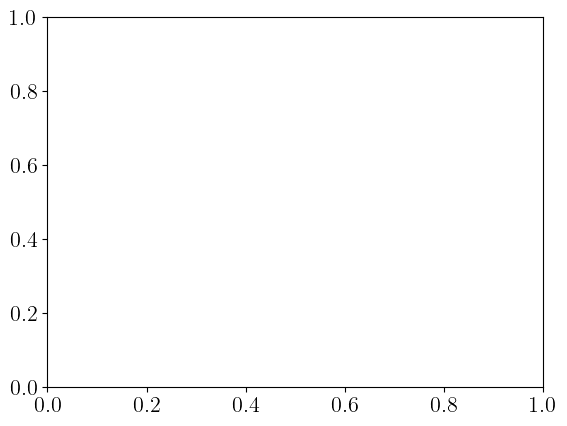

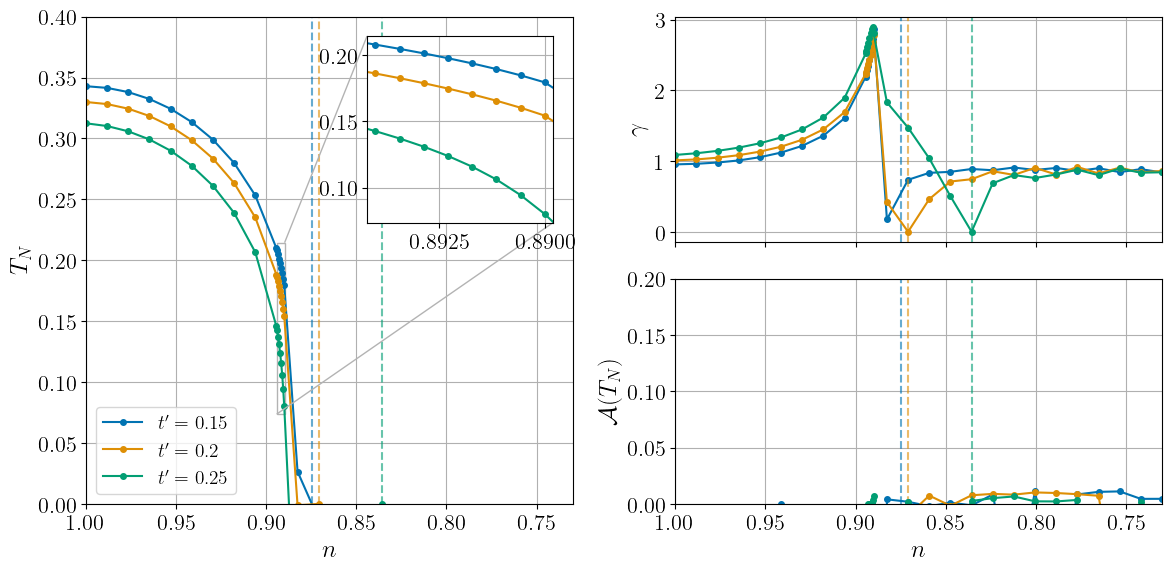

In [34]:
U = 3
tp_list = [0.15, 0.2, 0.25]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8898, 0.8942], subplots='commens')
plt.show()

plt.cla()
plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8898, 0.8942], subplots='scaling')
plt.show()